Author(s) : Daniel R., Tarry, Laura Gómez Navarro, Elisabet Verger-Miralles

Objective: Describe xxx

Created on: October 2023

Last updated on:


# Index / summary of steps:
## 1. Load data
## 2. Processing
    ## Identify large gaps
    ## Resampling to regular 10 min (1hr) intervals for surface (SVP) drifters
Calculate forward and backward velocities
Spike cleaning with velocity threshold (0.8 m/s)
Smoothing
Interpolation to fill gaps from removed spikes (linear)
Smoothing using a hamming window (2h for the surface drifters at the moment)
has context menu
Compose

# Testing the BC s for the smoothing with the hamming window (using mirrored BCs)

In [1]:
import time

print(time.ctime(time.time()))

Thu Nov 30 18:50:32 2023


In [2]:
# version_information

In [3]:
import numpy as np
import xarray as xr # version 0.20.1 necesarry, 0.16 gives error when calculating u_for
import matplotlib.pyplot as plt
import scipy.signal as signal

from read_data_tools_xr import latlon2uv_dir

In [4]:
print(xr.__version__)

2023.6.0


# Parameters:

In [5]:
url_drifter = 'drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?'
drifter_type = 'C' # C: CARTHE ; H: Hereon ; S: SVP-B 
diff_time_thres = 3600 # [s] 1h # Will be different for SVP, higher as time res. is 1hr

temp_res = 600. # Specifying seconds 
# Step depending on drifter (CARTHE and HEREON 600s (10 mins (we choose the highest time resolution)) 
# and SVP-B (1h))

# n_window = 12 # we leave like this for now

# CARTHE example

# 1. Loading the data:

In [6]:
# Main root
url_root = "http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/"

In [7]:
# parameters of the thredd file

if drifter_type == 'C':
    url_vars = "trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]"
else:
    print('Hereon is the same, add option, SVP missing temp , press , BAT_status different')
    fsdfs

In [8]:
url = url_root + url_drifter + url_vars
 
print(url)

http://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe011-ime_carthe006/L0/2023/dep0001_drifter-carthe011_ime-carthe006_L0_2023-04-27.nc?trajectory,time[0:1:-1],DEPTH,LAT[0:1:-1],LON[0:1:-1],BAT_STATUS[0:1:-1]


In [9]:
# Load file
ds = xr.open_dataset(url)


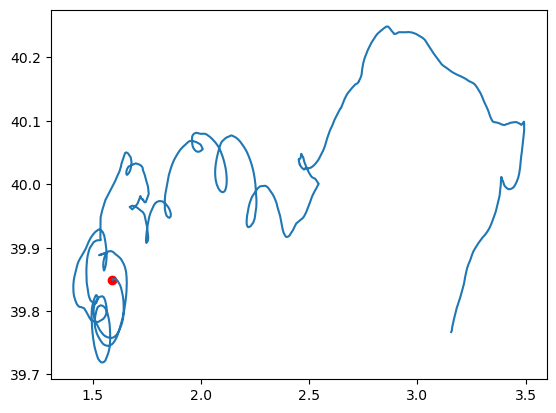

In [10]:
plt.plot(ds.LON, ds.LAT)
plt.scatter(ds.LON[0], ds.LAT[0], c='r')

# 2. Processing:

## 2.1. Identifying large time gaps (to kill drifter traj trash)

In [11]:
diff_time_thres = 3600 # [s] 1h

In [12]:
dt_drif = ds.time.diff("time").dt.seconds

In [13]:
inds_trash = np.where(dt_drif > diff_time_thres)

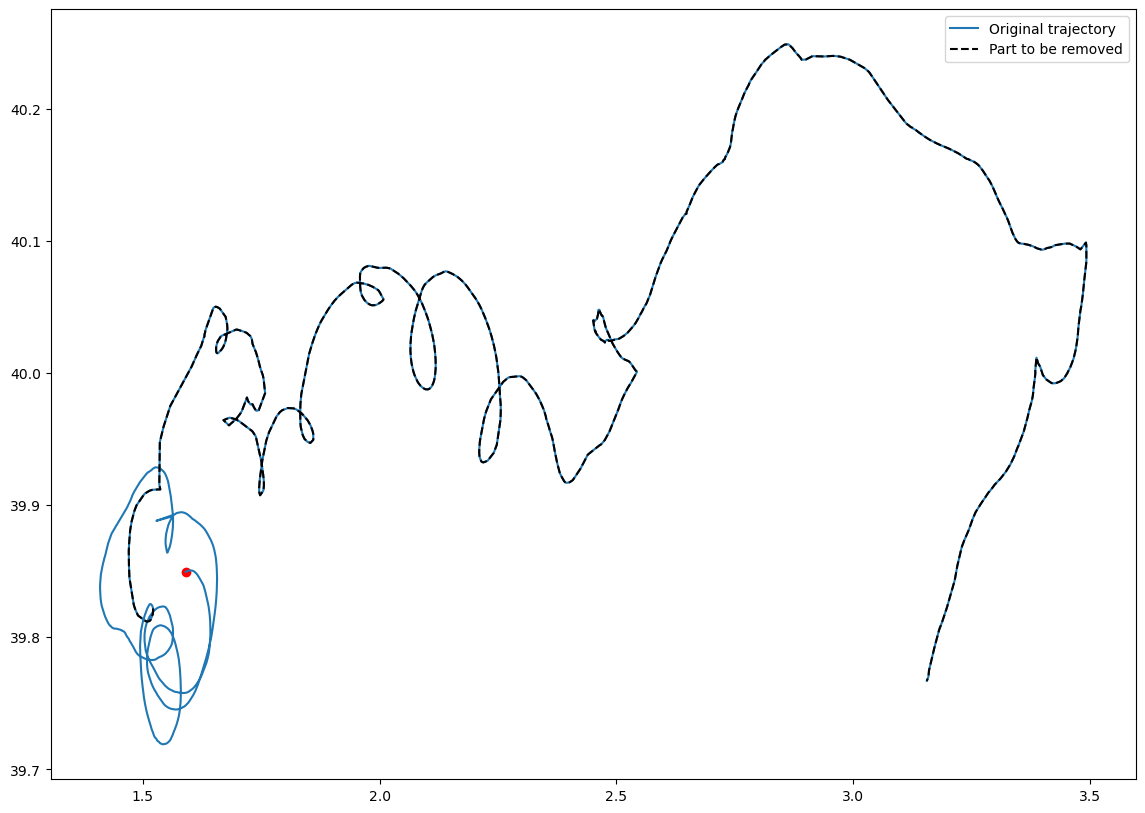

In [14]:
plt.figure(figsize=(14,10))
plt.plot(ds.LON, ds.LAT, label='Original trajectory')
plt.scatter(ds.LON[0], ds.LAT[0], c='r')
plt.plot(ds.LON[inds_trash[0][0]::], ds.LAT[inds_trash[0][0]::], '--k', label='Part to be removed')
plt.legend()

# --> in this case, 1 hour too conservative, let's try 2 hours:

In [15]:
diff_time_thres = 3600 * 2 # [s] 1h

In [16]:
dt_drif = ds.time.diff("time").dt.seconds

In [17]:
inds_trash = np.where(dt_drif > diff_time_thres)[0]

In [18]:
if inds_trash.size > 0: 
    ds01 = ds.where(ds.time<ds.time[inds_trash[0]+2], drop=True) # to improve 
    # + 2 because +1 of normal python indices , and 1 more because based on the indices of the array of time differences
elif inds_trash.size == 0:
    ds01 = ds.copy()
else:
    print('Problem')
    fsdgsdfg

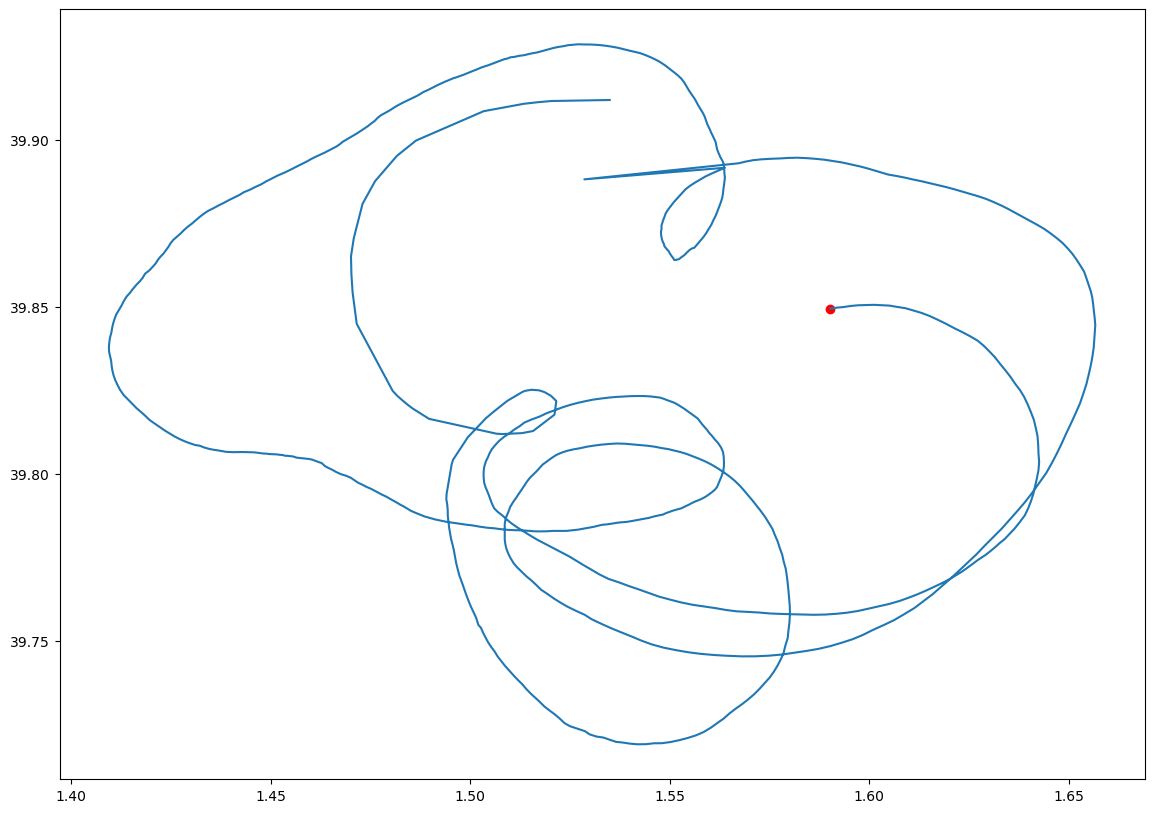

In [19]:
plt.figure(figsize=(14,10))
plt.plot(ds01.LON, ds01.LAT)
plt.scatter(ds01.LON[0], ds01.LAT[0], c='r')

# --> very short trajectory, very big jump seen above, could be that drogue lost, how to detect? Check with Brest people and Lara

## 2.2. Resampling to regular 10 mins. intervals:
(constant 10 mins and "o'clock" times)

### 2.2.1. Making lon and lat variables instead of coordinates
If we do not do this step when resampling we loose lon and lat in the dataset.  To keep in mind that this may give problems in further calculations with xarray that might need lon and lat as coords.

In [20]:
ds01 = ds01.reset_coords("LON")
ds01 = ds01.reset_coords("LAT")

### 2.2.2. Resampling:

In [21]:
ds02 = ds01.resample(time=f"{int(temp_res)}s").interpolate("linear") # xarray resample works very differently from pandas


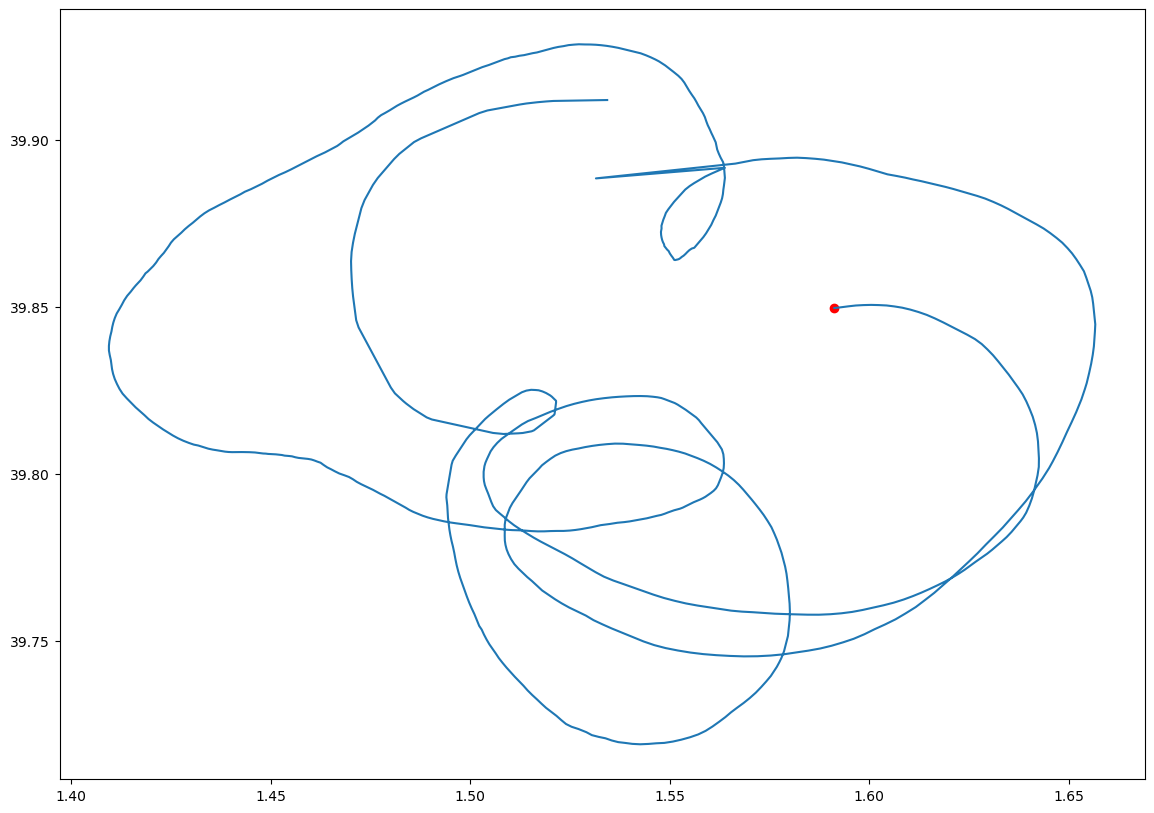

In [22]:
plt.figure(figsize=(14,10))
plt.plot(ds02.LON, ds02.LAT)
# plt.scatter(ds02.LON[0], ds02.LAT[0], c='r') # first point is nan now
plt.scatter(ds02.LON[1], ds02.LAT[1], c='r')

# --> spikes now smaller but still present
# To improve: maybe better to remove spikes with lon and lat (thres 0.02?) before resampling so that spike not spread

## 2.3. Calculate forward and backward velocities

blabla bla boundary conditions, back (t-1) , and forward (vel at t+1) calculated
# --> Dani

In [23]:
ufor, vfor, uvabsfor   = latlon2uv_dir(ds02['LAT'], ds02['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback, uvabsback = latlon2uv_dir(ds02['LON'], ds02['LAT'], temp_res, 'back')

In [24]:
# Add variables to the dataset
ds02 = ds02.assign(U=(ufor+uback)*0.5)
ds02 = ds02.assign(V=(vfor+vback)*0.5)
print(list(ds02.keys()))

['DEPTH', 'BAT_STATUS', 'LAT', 'LON', 'trajectory', 'U', 'V']


In [25]:
ds02.U.values

array([       nan, 0.12273186, 0.1334424 , ..., 0.1062631 , 0.10073366,
              nan])

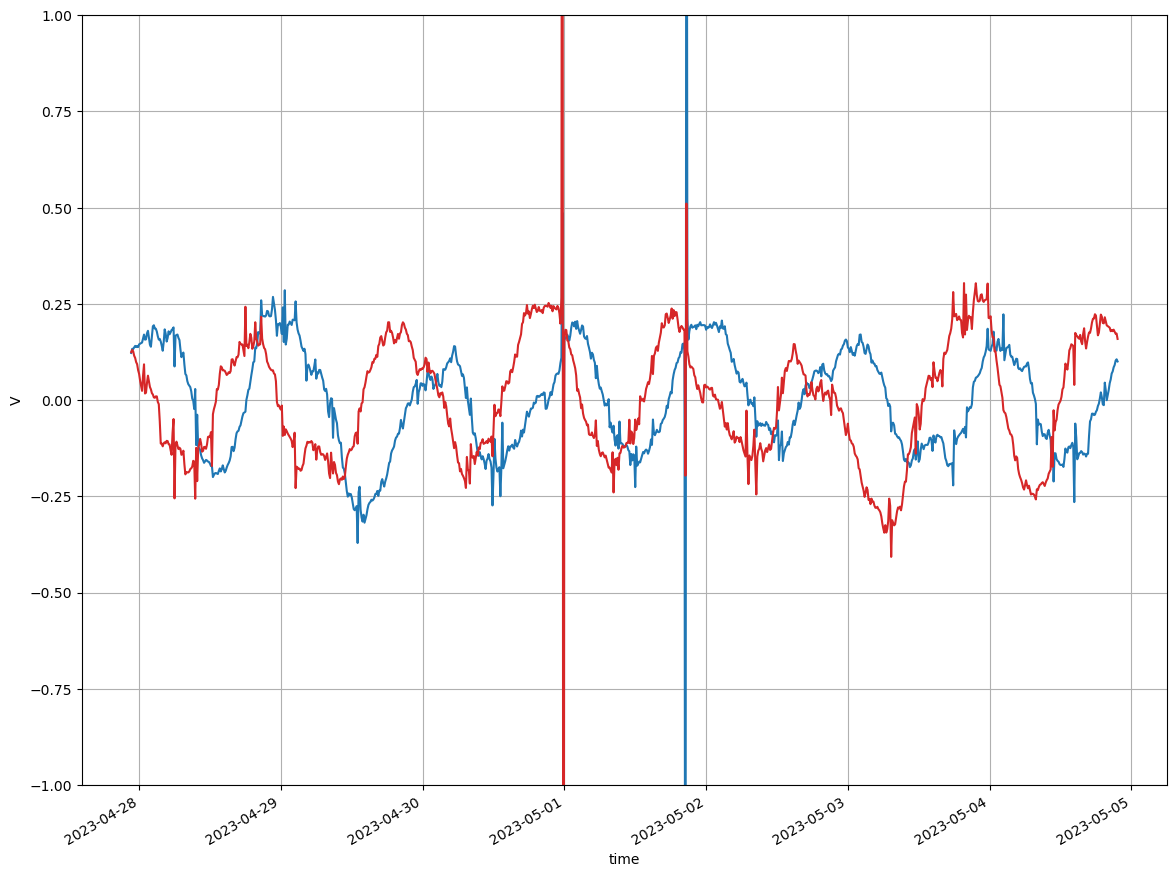

In [26]:
ds02.U.plot(figsize=(14,10))
ds02.V.plot(c='C3')
plt.ylim([-1, 1])
plt.grid()

# --> peaks not in phase, ok?

## 2.4. Spike cleaning:

Cleaning spikes now based on velocity thresholds(absolute velocity (speed))

In [27]:
abs_vel = (ds02.U**2 + ds02.V**2)**0.5

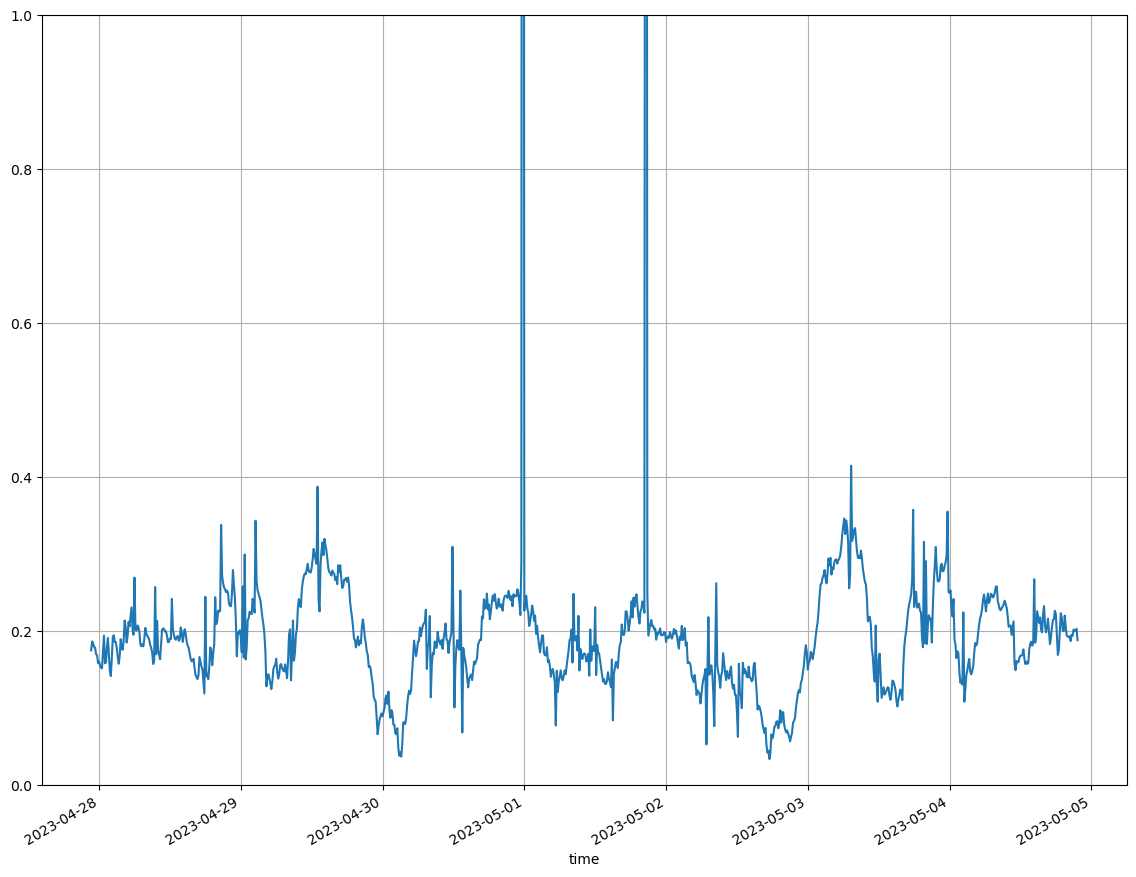

In [28]:
abs_vel.plot(figsize=(14,10))
plt.ylim([0,1])
plt.grid()

Based on above plot we choose 0.8 m/s.

To improve:
- big spike cleaning with lon and lat thres. before resmpling
- do a moving vel. thres.
- would be better to filter spikes on acceleration, but harder then to choose threshold (less intuitive)

In [29]:
vel_thres = 0.8 # m/s 

In [30]:
ds03 = ds02.where(abs_vel < vel_thres)

In [31]:
abs_vel_new = (ds03.U**2 + ds03.V**2)**0.5

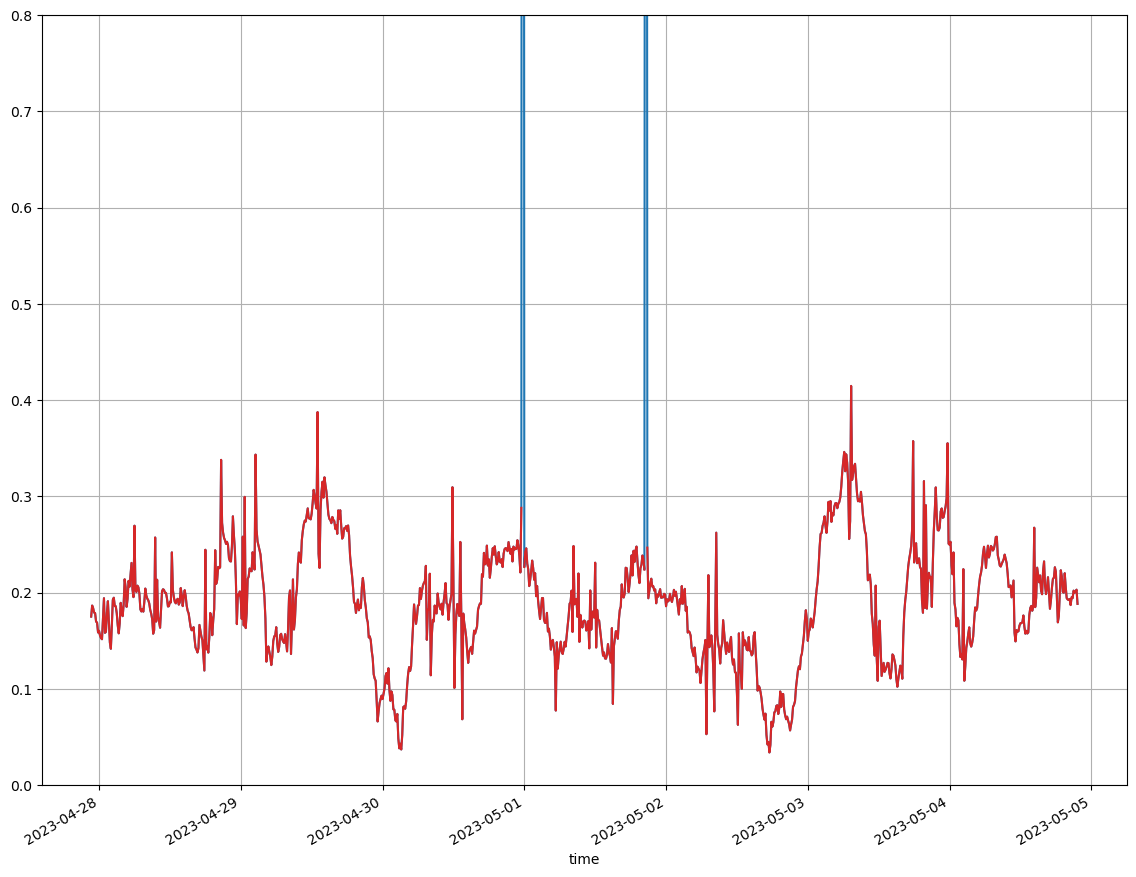

In [32]:
abs_vel.plot(figsize=(14,10))
abs_vel_new.plot(c='C3')
plt.ylim([0,0.8])
plt.grid()

## 2.5. Smoothing

### 2.5.1. Interpolation
(again to fill in spike gaps, smoothing method applied (for now) next does not fill in the gaps) --> to check

In [33]:
# To apply interpolate, we need to remove the trajectory variable because it is a string not a float (number)
ds03 = ds03.drop_vars("trajectory") # trajectory variable unnecessary, check with Lara --> not better attrubte?

In [34]:
ds04 = ds03.interpolate_na(dim='time', method="pchip") 
# Pchip : cubic with splines interp. (Dani find ref.)

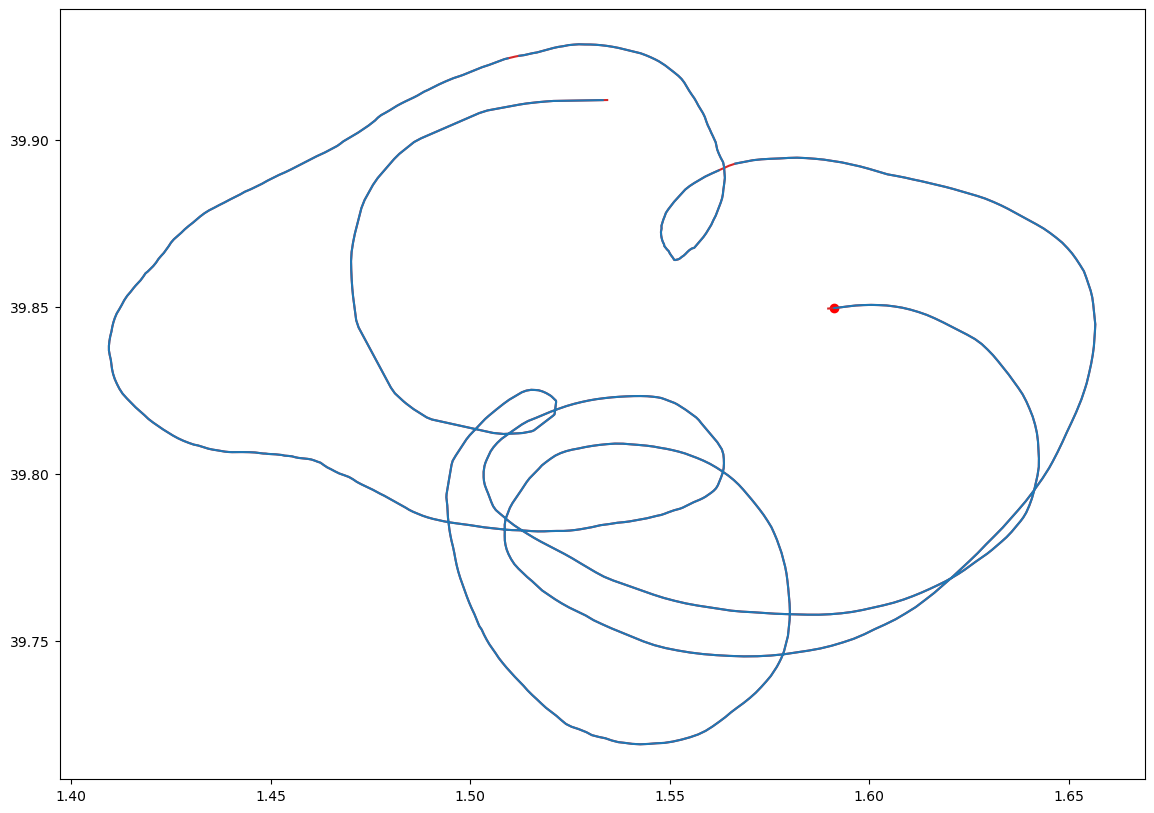

In [35]:
plt.figure(figsize=(14,10))
plt.plot(ds04.LON, ds04.LAT, 'C3')
plt.plot(ds03.LON, ds03.LAT)
plt.scatter(ds04.LON[1], ds04.LAT[1], c='r')

### 2.5.2. Applying smoothing
To remove small scale noise and any remaining spikes.

(we apply window to smooth the data on the lon and lat drifters, to the recalculate vels (could also apply directly on vels... we will see later) )


# --> for now we leave it at n=12 <-> 2h (method to be refined as smoothes too much at peaks, very flat)

https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.convolve.html

# We did testing with abs_vel, to check smoothing method and window size, and then applied it on lon and lat.

#### Smoothing on lon and lat:

In [36]:
ds05 = ds04.copy()

In [37]:
ds05

<xarray.Dataset>
Dimensions:     (time: 1005)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-27T22:30:00 ... 2023-05-04T21:5...
Data variables:
    DEPTH       (time) float64 0.6 0.6 0.6 0.6 0.6 0.6 ... 0.6 0.6 0.6 0.6 0.6
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.85 39.85 39.85 39.85 ... 39.91 39.91 39.91
    LON         (time) float64 1.59 1.591 1.593 1.595 ... 1.532 1.533 1.534
    U           (time) float64 0.1114 0.1227 0.1334 ... 0.1063 0.1007 0.08811
    V           (time) float64 0.1124 0.125 0.1306 ... 0.1732 0.1592 0.1445
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE006 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE006 in FaSt-...
    summary:                             Deployment of IME-CARTHE006 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

# Create new variables with mirror BCs:

In [38]:
# ds05["LON"] = ds04.LON.rolling(time=12, center=True).median()
# ds05["LAT"] = ds04.LAT.rolling(time=12, center=True).median()

window = signal.windows.hamming(12) # 2 hours (12 points) 



In [39]:
nn = 100
lonb = ds04.LON.values
lona = np.flipud(ds04.LON.values[0:nn])
lonc = np.flipud(ds04.LON.values[-nn::])

latb = ds04.LAT.values
lata = np.flipud(ds04.LAT.values[0:nn])
latc = np.flipud(ds04.LAT.values[-nn::])

In [40]:
lon_cat = np.concatenate((lona, lonb, lonc))
lat_cat = np.concatenate((lata, latb, latc))

In [41]:
print(lonb.shape)
print(lon_cat.shape)
print(lon_cat[nn:-nn].shape)

(1005,)
(1205,)
(1005,)


In [42]:
print(lon_cat[nn])
print(lonb[0])

1.5897436180718583
1.5897436180718583


In [43]:
# --> ok

In [44]:
lon_win = signal.convolve(lon_cat, window, mode='same') / np.sum(window)
ds05["LON"][:] = lon_win[nn:-nn]

lat_win = signal.convolve(lat_cat, window, mode='same') / np.sum(window)
ds05["LAT"][:] = lat_win[nn:-nn]
# ds05["LAT"][:] = signal.convolve(ds04.LAT, window, mode='same') / np.sum(window)


In [45]:
ds05

<xarray.Dataset>
Dimensions:     (time: 1005)
Coordinates:
  * time        (time) datetime64[ns] 2023-04-27T22:30:00 ... 2023-05-04T21:5...
Data variables:
    DEPTH       (time) float64 0.6 0.6 0.6 0.6 0.6 0.6 ... 0.6 0.6 0.6 0.6 0.6
    BAT_STATUS  (time) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    LAT         (time) float64 39.85 39.85 39.85 39.85 ... 39.91 39.91 39.91
    LON         (time) float64 1.592 1.592 1.593 1.594 ... 1.531 1.532 1.533
    U           (time) float64 0.1114 0.1227 0.1334 ... 0.1063 0.1007 0.08811
    V           (time) float64 0.1124 0.125 0.1306 ... 0.1732 0.1592 0.1445
Attributes: (12/67)
    title:                               Data from instrument IME-CARTHE006 o...
    institution:                         IMEDEA (Instituto MEDiterráneo de Es...
    netcdf_version:                      3.0
    Conventions:                         CF-1.6
    abstract:                            Deployment of IME-CARTHE006 in FaSt-...
    summary:                             Deployment of IME-CARTHE006 in FaSt-...
    ...                                  ...
    citation:                            Balearic Island Coastal and Observin...
    acknowledgement:                     The FaSt-SWOT project is funded by t...
    update_interval:                     every 3600 seconds
    DODS.strlen:                         34
    DODS.dimName:                        name_strlen
    DODS_EXTRA.Unlimited_Dimension:      time

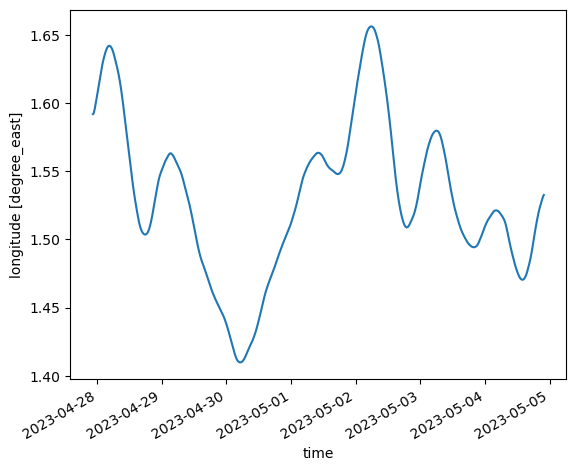

In [46]:
ds05.LON.plot()

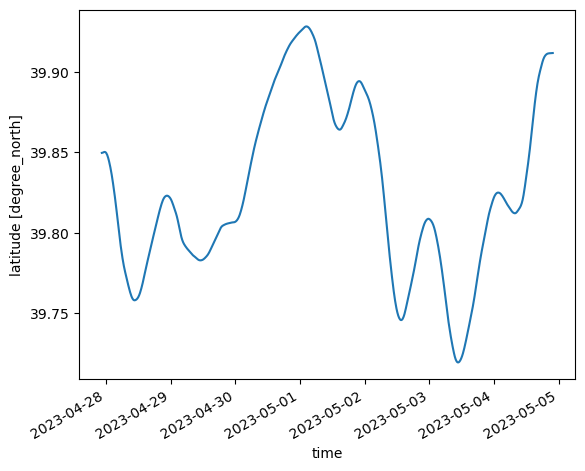

In [47]:
ds05.LAT.plot()

# --> no more weird dips in LON at extremes --> to be fixed (mentioned above)

# Recalculate U and V:

In [43]:
ufor, vfor, uvabsfor   = latlon2uv_dir(ds05['LAT'], ds05['LON'], temp_res, 'for') # 600 = temporal resolution
uback, vback, uvabsback = latlon2uv_dir(ds05['LON'], ds05['LAT'], temp_res, 'back')

In [44]:
# Add variables to the dataset
ds05 = ds05.assign(U=(ufor+uback)*0.5)
ds05 = ds05.assign(V=(vfor+vback)*0.5)
print(list(ds05.keys()))

['DEPTH', 'BAT_STATUS', 'LAT', 'LON', 'U', 'V']


# Battery:

https://thredds.socib.es/thredds/dodsC/drifter/surface_drifter/drifter_carthe036-scb_carthe017/L0/2023/dep0001_drifter-carthe036_scb-carthe017_L0_2023-09-07.nc.html

0 = Low battery, 1 = good

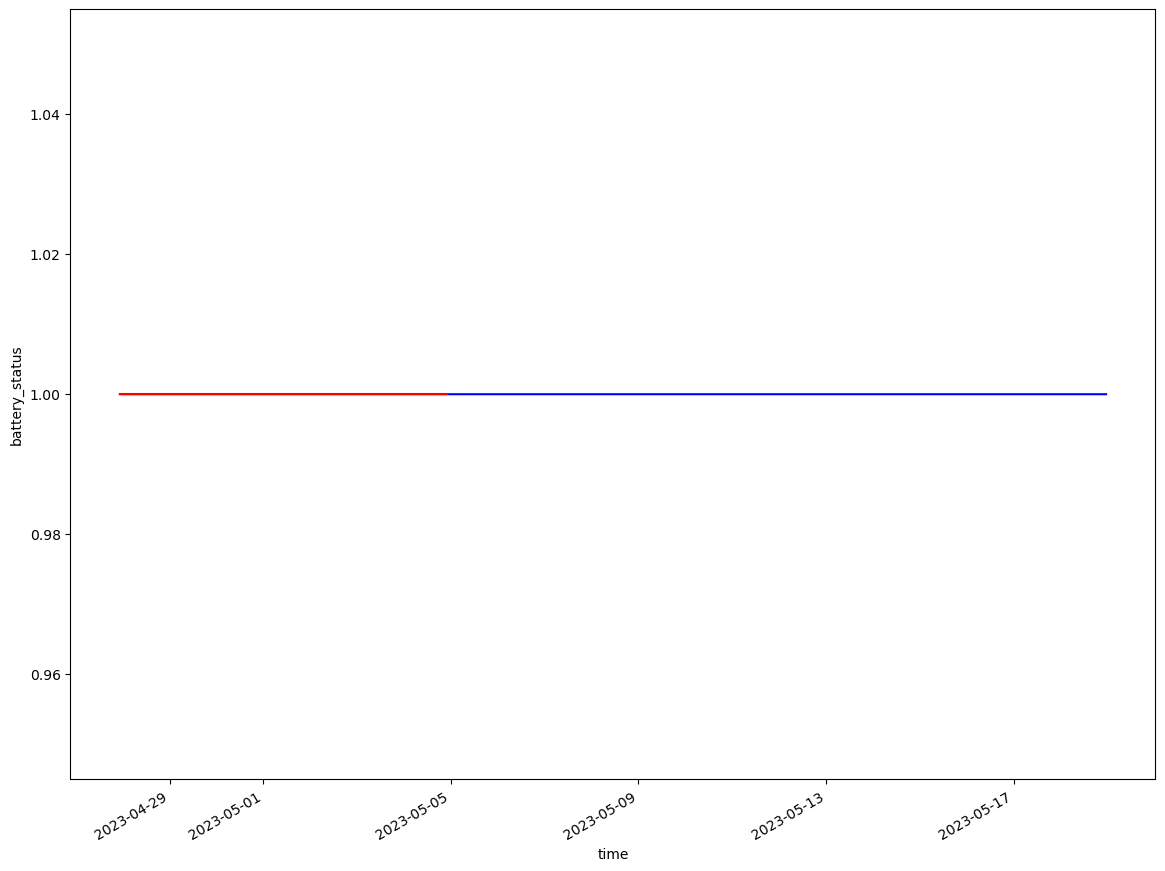

In [45]:
ds.BAT_STATUS.plot(figsize=(14,10), c='b')
ds05.BAT_STATUS.plot(c='r')

# --> well cut already in terms of battery (in this case)

# Flags:

# --> later

# 3. Saving the data

In [50]:
# rootdir =
!ls ~/../../

Applications Users        cores        home         sbin         var
Library      Volumes      dev          opt          tmp
System       bin          etc          private      usr


In [ ]:
outdir = OS + 'data/drifters/L1_IMEDEA/'

In [51]:
url_drifter.split('/')[0]

'drifter_carthe011-ime_carthe006'

In [46]:
# ds05.to_netcdf(rootdir + outdir + url_drifter.split('/')[0] + '.nc')